===== DESCRIÇÃO DO DATASET ====
Nome do Dataset: Microdados do ENEM
Link Original: https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/enem
Órgão Responsável: INEP - Instituto Nacional de Estudos e Pesquisas Educacionais Anísio Teixeira
Tema e Finalidade: 
Os microdados do ENEM contêm informações detalhadas sobre os participantes do exame,
incluindo notas nas provas e dados socioeconômicos. Permitem análises estatísticas
educacionais sobre o desempenho dos estudantes no Brasil.


Carregando dataset completo (pode demorar)...

Dataset reduzido para 100000 registros.

Primeiras linhas:
        NU_INSCRICAO  NU_ANO  TP_FAIXA_ETARIA TP_SEXO  TP_ESTADO_CIVIL  \
266100  210056902675    2022                3       F                1   
637785  210057568265    2022                2       F                1   
691010  210056042951    2022                2       F                1   
497259  210055256380    2022                6       F                1   
796474  21005614

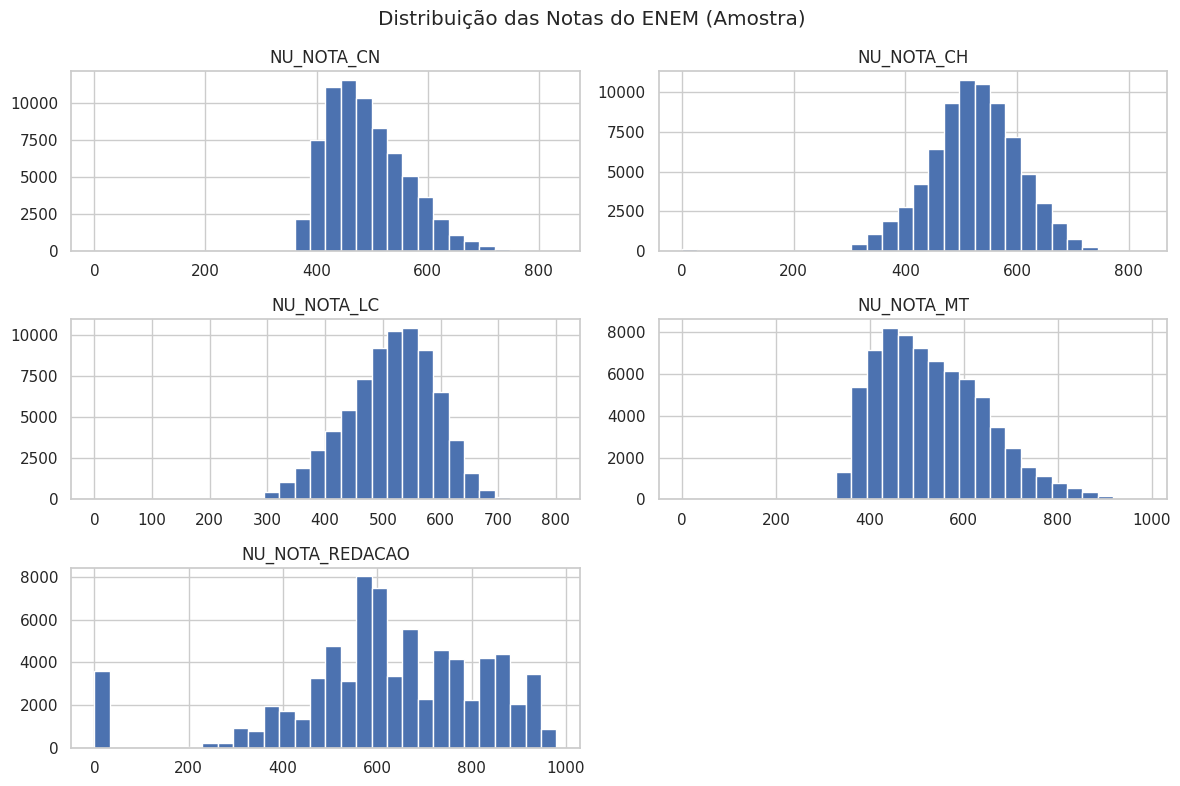

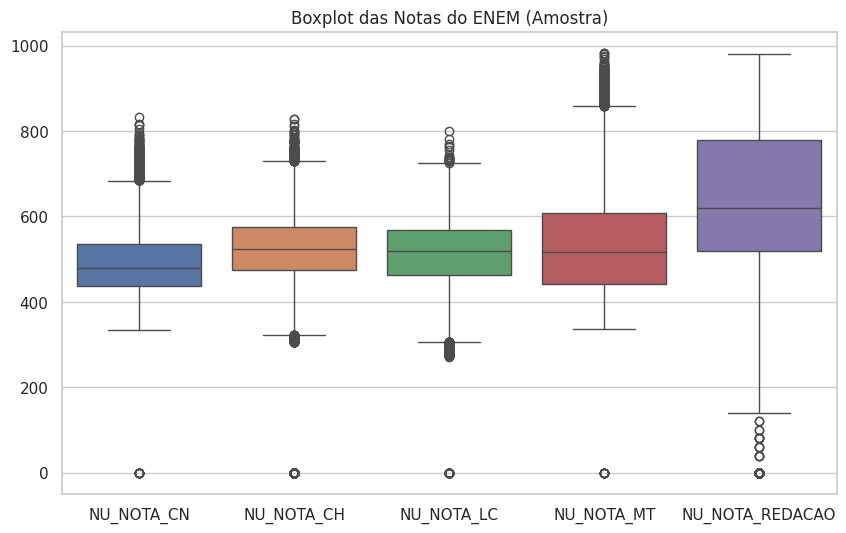

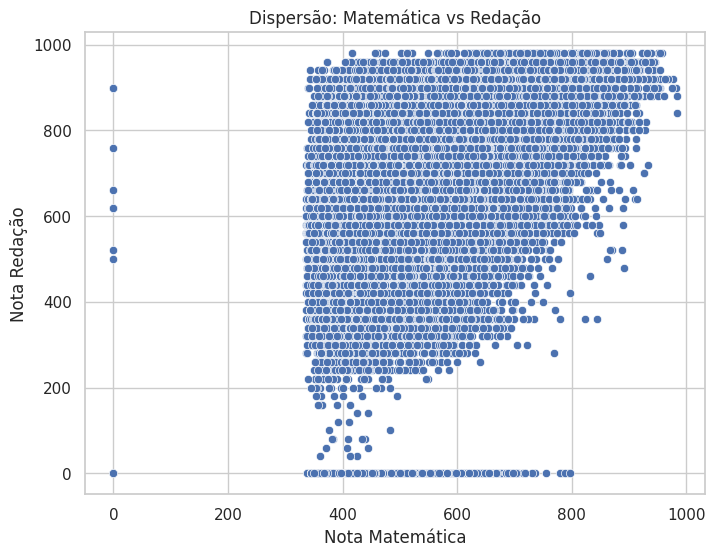


===== ANÁLISE DOS RESULTADOS ====

NU_NOTA_CN:
Média = 490.73
Mediana = 479.50
Desvio Padrão = 70.89
Distribuição assimétrica à direita.

NU_NOTA_CH:
Média = 523.63
Mediana = 524.80
Desvio Padrão = 80.28
Distribuição assimétrica à esquerda.

NU_NOTA_LC:
Média = 513.33
Mediana = 520.20
Desvio Padrão = 77.03
Distribuição assimétrica à esquerda.

NU_NOTA_MT:
Média = 532.67
Mediana = 517.40
Desvio Padrão = 113.91
Distribuição assimétrica à direita.

NU_NOTA_REDACAO:
Média = 623.19
Mediana = 620.00
Desvio Padrão = 211.20
Distribuição assimétrica à direita.

Análise concluída com sucesso!


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# 1. DESCRIÇÃO DO DATASET
# =====================================================
NOME_DATASET = "Microdados do ENEM"
LINK_DATASET = "https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/enem"
ORGAO_RESPONSAVEL = "INEP - Instituto Nacional de Estudos e Pesquisas Educacionais Anísio Teixeira"

DESCRICAO = """
Os microdados do ENEM contêm informações detalhadas sobre os participantes do exame,
incluindo notas nas provas e dados socioeconômicos. Permitem análises estatísticas
educacionais sobre o desempenho dos estudantes no Brasil.
"""

print("===== DESCRIÇÃO DO DATASET ====")
print(f"Nome do Dataset: {NOME_DATASET}")
print(f"Link Original: {LINK_DATASET}")
print(f"Órgão Responsável: {ORGAO_RESPONSAVEL}")
print(f"Tema e Finalidade: {DESCRICAO}")

# =====================================================
# 2. CARREGAMENTO DO DATASET (COM REDUÇÃO)
# =====================================================
caminho_arquivo = "DADOS/MICRODADOS_ENEM_2022.csv"

print("\nCarregando dataset completo (pode demorar)...")
df_full = pd.read_csv(caminho_arquivo, sep=";", encoding="latin1", low_memory=False)

# Redução para amostra aleatória
AMOSTRA = 100000  # ajuste se quiser (ex: 50000 ou 200000)
df = df_full.sample(n=AMOSTRA, random_state=42)

print(f"\nDataset reduzido para {AMOSTRA} registros.")

print("\nPrimeiras linhas:")
print(df.head())

# =====================================================
# 3. INFORMAÇÕES GERAIS
# =====================================================
print("\n===== INFORMAÇÕES GERAIS ====")
print(f"Número de registros: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")

print("\nTipos de dados:")
print(df.dtypes)

print("\nResumo geral:")
df.info()

# =====================================================
# 4. VARIÁVEIS IMPORTANTES (NOTAS)
# =====================================================
colunas_notas = [
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT",
    "NU_NOTA_REDACAO"
]

colunas_existentes = [col for col in colunas_notas if col in df.columns]
notas = df[colunas_existentes]

print("\nColunas utilizadas:")
print(colunas_existentes)

# =====================================================
# 5. SIGNIFICADO DAS VARIÁVEIS
# =====================================================
print("\n===== SIGNIFICADO DAS VARIÁVEIS ====")
print("NU_NOTA_CN - Nota em Ciências da Natureza")
print("NU_NOTA_CH - Nota em Ciências Humanas")
print("NU_NOTA_LC - Nota em Linguagens")
print("NU_NOTA_MT - Nota em Matemática")
print("NU_NOTA_REDACAO - Nota da Redação")

# =====================================================
# 6. ESTATÍSTICAS DESCRITIVAS
# =====================================================
print("\n===== ESTATÍSTICAS DESCRITIVAS ====")

media = notas.mean()
mediana = notas.median()
moda = notas.mode().iloc[0]

minimo = notas.min()
maximo = notas.max()

desvio_padrao = notas.std()
variancia = notas.var()

quartis = notas.quantile([0.25, 0.5, 0.75])
iqr = quartis.loc[0.75] - quartis.loc[0.25]

print("\nMédia:\n", media)
print("\nMediana:\n", mediana)
print("\nModa:\n", moda)
print("\nMínimo:\n", minimo)
print("\nMáximo:\n", maximo)
print("\nDesvio Padrão:\n", desvio_padrao)
print("\nVariância:\n", variancia)
print("\nQuartis:\n", quartis)
print("\nIQR:\n", iqr)

# =====================================================
# 7. VALORES AUSENTES
# =====================================================
print("\n===== VALORES AUSENTES ====")
print(notas.isnull().sum())

# =====================================================
# 8. VISUALIZAÇÕES
# =====================================================
sns.set(style="whitegrid")

notas.hist(bins=30, figsize=(12, 8))
plt.suptitle("Distribuição das Notas do ENEM (Amostra)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=notas)
plt.title("Boxplot das Notas do ENEM (Amostra)")
plt.show()

if "NU_NOTA_MT" in notas.columns and "NU_NOTA_REDACAO" in notas.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df["NU_NOTA_MT"], y=df["NU_NOTA_REDACAO"])
    plt.title("Dispersão: Matemática vs Redação")
    plt.xlabel("Nota Matemática")
    plt.ylabel("Nota Redação")
    plt.show()

# =====================================================
# 9. ANÁLISE AUTOMÁTICA
# =====================================================
print("\n===== ANÁLISE DOS RESULTADOS ====")

for col in colunas_existentes:
    print(f"\n{col}:")
    print(f"Média = {media[col]:.2f}")
    print(f"Mediana = {mediana[col]:.2f}")
    print(f"Desvio Padrão = {desvio_padrao[col]:.2f}")

    if media[col] > mediana[col]:
        print("Distribuição assimétrica à direita.")
    elif media[col] < mediana[col]:
        print("Distribuição assimétrica à esquerda.")
    else:
        print("Distribuição aproximadamente simétrica.")

print("\nAnálise concluída com sucesso!")